In [7]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [8]:
# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-total-female-births.csv"
df = pd.read_csv(url)

print(df.head())
print("\nShape:", df.shape)
print("\nDescription:")
print(df.describe())

         Date  Births
0  1959-01-01      35
1  1959-01-02      32
2  1959-01-03      30
3  1959-01-04      31
4  1959-01-05      44

Shape: (365, 2)

Description:
           Births
count  365.000000
mean    41.980822
std      7.348257
min     23.000000
25%     37.000000
50%     42.000000
75%     46.000000
max     73.000000


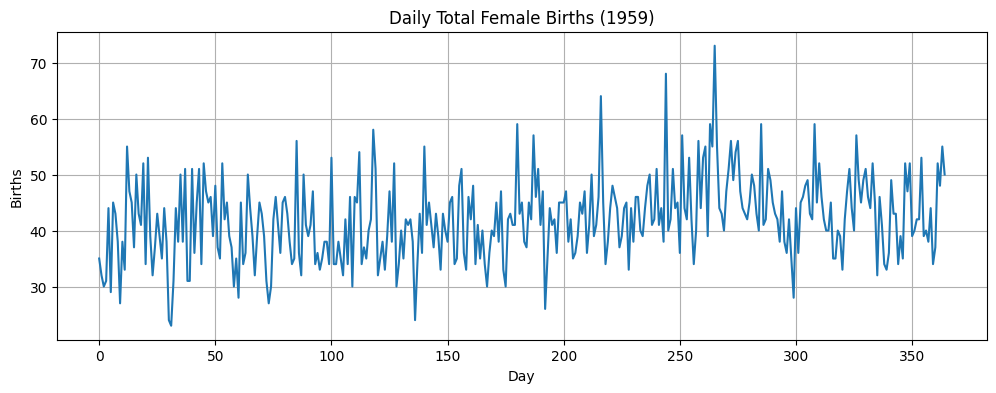

In [9]:
# Step 3: Visualize Dataset
plt.figure(figsize=(12, 4))
plt.plot(df['Births'])
plt.title("Daily Total Female Births (1959)")
plt.xlabel("Day")
plt.ylabel("Births")
plt.grid(True)
plt.show()

In [10]:
# Step 4: Normalize Data and Create Sequences
scaler = MinMaxScaler()
dataset = scaler.fit_transform(df[['Births']])

time_step = 10
X, y = [], []

for i in range(len(dataset) - time_step):
    X.append(dataset[i : i + time_step])
    y.append(dataset[i + time_step])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (355, 10, 1)
y shape: (355, 1)


In [11]:
# Step 5: Split Dataset
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 284
Testing Samples: 71


In [12]:
# ─── PART 1: Simple RNN ───────────────────────────────────────────────────────

# Step 6: Build and Train Simple RNN
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(time_step, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)
print("RNN Training Completed!")

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0404 - val_loss: 0.0204
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0230 - val_loss: 0.0212
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0223 - val_loss: 0.0172
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0212 - val_loss: 0.0192
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0244 - val_loss: 0.0169
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0219 - val_loss: 0.0171
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 - val_loss: 0.0182
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0214 - val_loss: 0.0188
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0211 - val_loss: 0.0172
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0210 - val_loss: 0.0229
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0220 - val_loss: 0.0176
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0224 - val_l

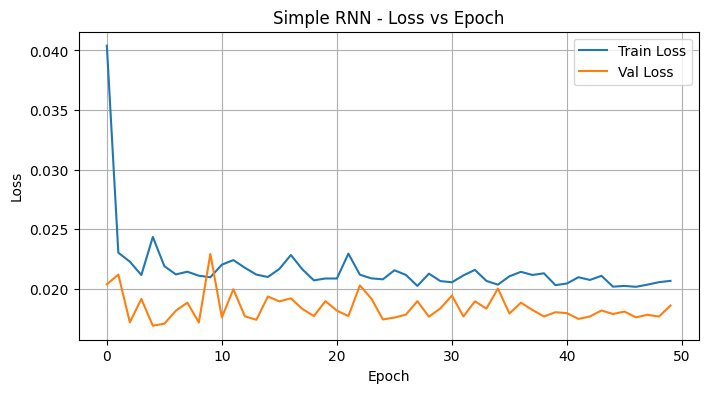

In [13]:
# Step 7: Plot RNN Loss
plt.figure(figsize=(8, 4))
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Val Loss')
plt.title("Simple RNN - Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Step 8: RNN Predictions and Evaluation
rnn_pred = scaler.inverse_transform(rnn_model.predict(X_test))
actual   = scaler.inverse_transform(y_test)

print("Simple RNN Metrics:")
print("MSE :", mean_squared_error(actual, rnn_pred))
print("RMSE:", np.sqrt(mean_squared_error(actual, rnn_pred)))
print("MAE :", mean_absolute_error(actual, rnn_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Simple RNN Metrics:
MSE : 46.532023580947154
RMSE: 6.821438527242414
MAE : 5.532855342811262


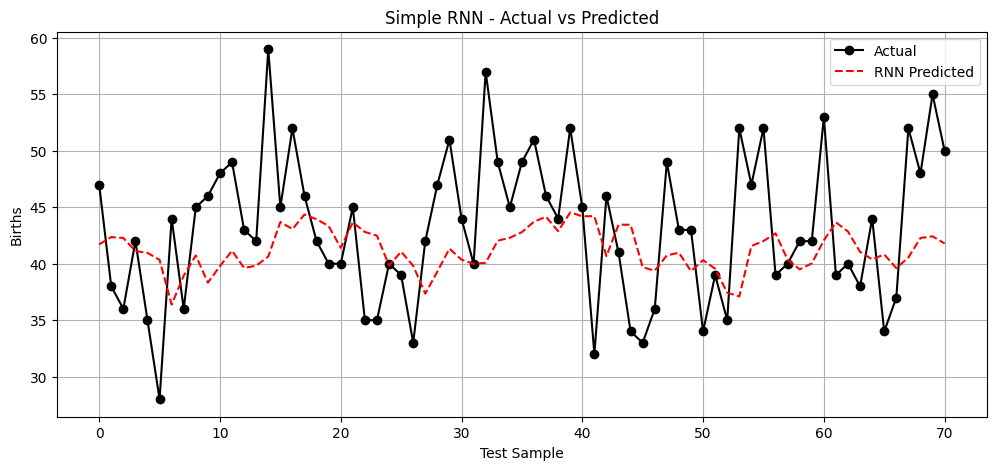

In [15]:
# Step 9: RNN Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='black', marker='o')
plt.plot(rnn_pred, label='RNN Predicted', color='red', linestyle='--')
plt.title("Simple RNN - Actual vs Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Births")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ─── PART 2: LSTM ────────────────────────────────────────────────────────────

# Step 10: Build and Train LSTM
lstm_model = Sequential([
    LSTM(32, input_shape=(time_step, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)
print("LSTM Training Completed!")

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0416 - val_loss: 0.0188
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0209 - val_loss: 0.0191
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0210 - val_loss: 0.0184
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0207 - val_loss: 0.0183
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0205 - val_loss: 0.0188
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0211 - val_loss: 0.0187
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0207 - val_loss: 0.0198
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0183
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0206 - val_loss: 0.0184
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0211 - val_loss: 0.0183
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0206 - val_loss: 0.0181
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0205 - val_l

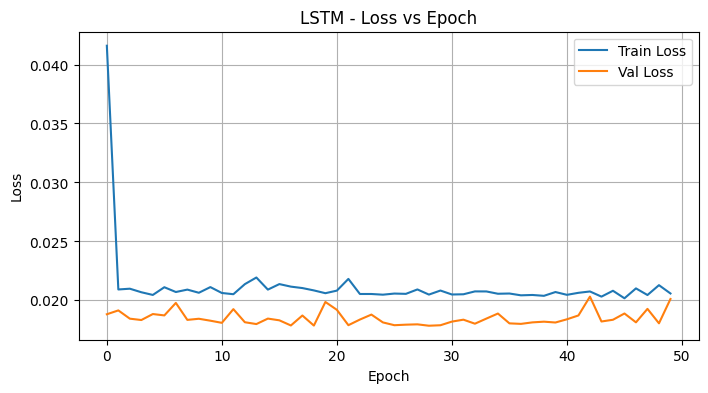

In [17]:
# Step 11: Plot LSTM Loss
plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title("LSTM - Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Step 12: LSTM Predictions and Evaluation
lstm_pred = scaler.inverse_transform(lstm_model.predict(X_test))

print("LSTM Metrics:")
print("MSE :", mean_squared_error(actual, lstm_pred))
print("RMSE:", np.sqrt(mean_squared_error(actual, lstm_pred)))
print("MAE :", mean_absolute_error(actual, lstm_pred))

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000015106366DE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
LSTM Metrics:
MSE : 50.29385978068101
RMSE: 7.091816395020461
MAE : 5.909370153722628


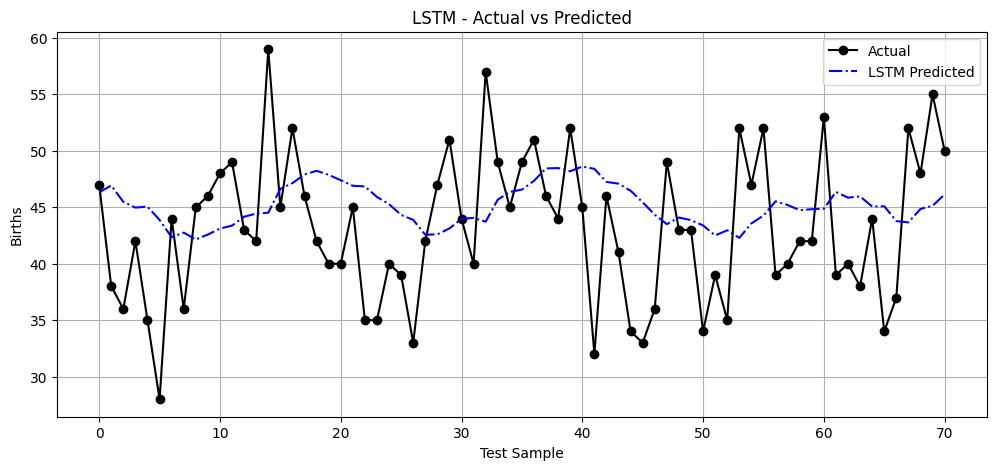

In [19]:
# Step 13: LSTM Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='black', marker='o')
plt.plot(lstm_pred, label='LSTM Predicted', color='blue', linestyle='-.')
plt.title("LSTM - Actual vs Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Births")
plt.legend()
plt.grid(True)
plt.show()